# Commercial Binary Classification

This notebook trains and evaluates the binary classifier that separates commercial buildings from the remaining building classes. Feature selection, hyperparameter optimization, model comparison, and final model training are performed for this classification task.

**Input**
- Preprocessed training, validation, and test data for commercial versus other-building classification.
- Candidate machine-learning features.

**Output**
- Selected features for commercial binary classification.
- Optimized and evaluated classification models.
- Final trained commercial binary classifier and associated model parameters.

In [1]:
import numpy as np
import pandas as pd
import joblib
import os
import json
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import StratifiedShuffleSplit


import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)

ROOT_DIR  = '/fast/home/o-olajuyigbe/osm_project'
ML_DIR    = os.path.join(ROOT_DIR, 'data', 'ml_ready')
MODEL_DIR = os.path.join(ROOT_DIR, 'data', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# LEVEL Options: 'flat_l1', 'flat_l2', 'l0_res_binary', 'l1a_res_subtypes',
#          'l1b_ind_binary', 'l2a_ind_subtypes', 'l2b_comm_binary', 'l3a_comm_subtypes'
LEVEL = 'l2b_comm_binary'

print(f"Training level: {LEVEL}")

Training level: l2b_comm_binary


/fast/home/o-olajuyigbe/miniforge3/envs/osm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train, y_train = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_train_raw.pkl'))
X_val,   y_val   = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_val_raw.pkl'))
X_test,  y_test  = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_test_raw.pkl'))
classes          = joblib.load(os.path.join(ML_DIR, f'{LEVEL}_classes.pkl'))
candidate_features = joblib.load(os.path.join(ML_DIR, 'candidate_features.pkl'))


print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Classes : {classes}")

n_classes = len(np.unique(y_train))

# print class count fot trainin, test and validation sets
print("\nClass distribution in training set:")
print(np.bincount(y_train))
print("\nClass distribution in validation set:")
print(np.bincount(y_val))
print("\nClass distribution in test set:")
print(np.bincount(y_test))

X_train : (915114, 110)
X_val   : (53831, 110)
X_test  : (107660, 110)
Classes : ['other' 'commercial']

Class distribution in training set:
[557339 357775]

Class distribution in validation set:
[32785 21046]

Class distribution in test set:
[65569 42091]


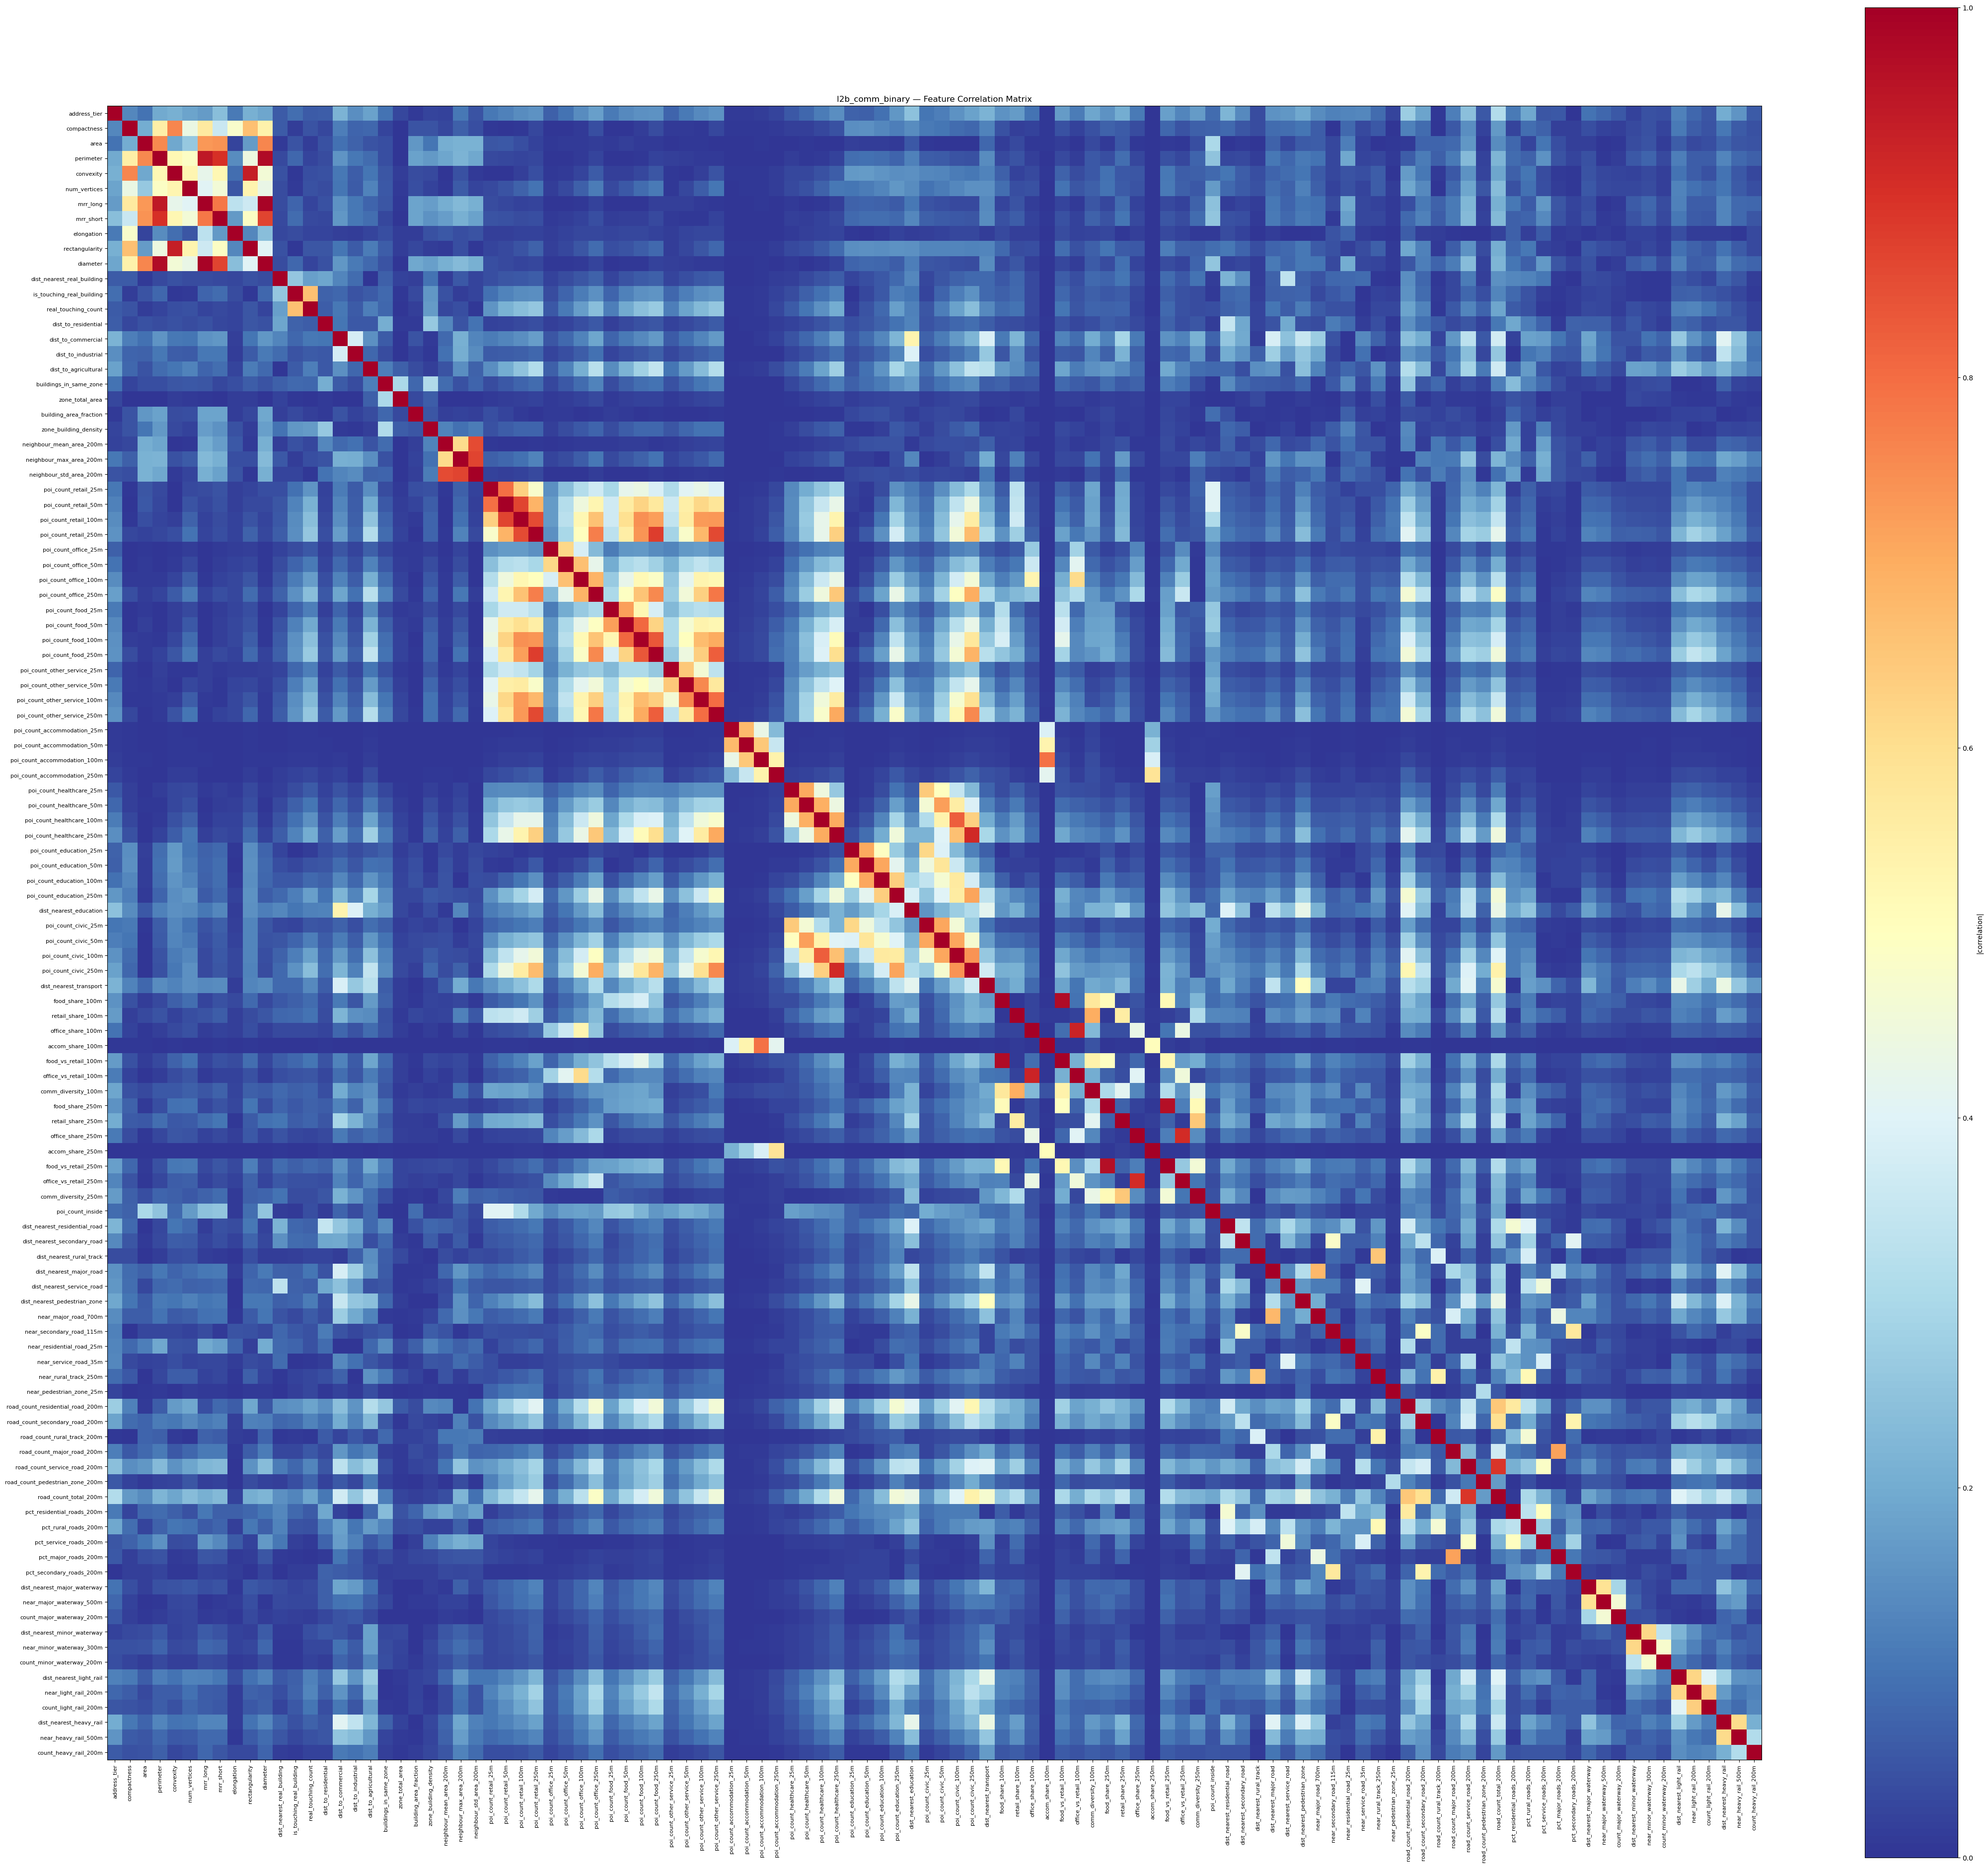

In [3]:
# Correlation Heatmap

corr_matrix = X_train[candidate_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(candidate_features)*0.4), max(6, len(candidate_features)*0.35)))
im = ax.imshow(corr_matrix, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(candidate_features)))
ax.set_yticks(range(len(candidate_features)))
ax.set_xticklabels(candidate_features, rotation=90, fontsize=8)
ax.set_yticklabels(candidate_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Excluded features (correlation <= 0.7 with all other features):
['address_tier', 'num_vertices', 'elongation', 'dist_nearest_real_building', 'is_touching_real_building', 'real_touching_count', 'dist_to_residential', 'dist_to_commercial', 'dist_to_industrial', 'dist_to_agricultural', 'buildings_in_same_zone', 'zone_total_area', 'building_area_fraction', 'zone_building_density', 'poi_count_office_25m', 'poi_count_office_50m', 'poi_count_office_100m', 'poi_count_other_service_25m', 'poi_count_accommodation_25m', 'poi_count_accommodation_50m', 'poi_count_accommodation_250m', 'dist_nearest_education', 'dist_nearest_transport', 'retail_share_100m', 'comm_diversity_100m', 'retail_share_250m', 'accom_share_250m', 'comm_diversity_250m', 'poi_count_inside', 'dist_nearest_residential_road', 'dist_nearest_secondary_road', 'dist_nearest_rural_track', 'dist_nearest_major_road', 'dist_nearest_service_road', 'dist_nearest_pedestrian_zone', 'near_major_road_700m', 'near_secondary_road_115m', 'near_resi

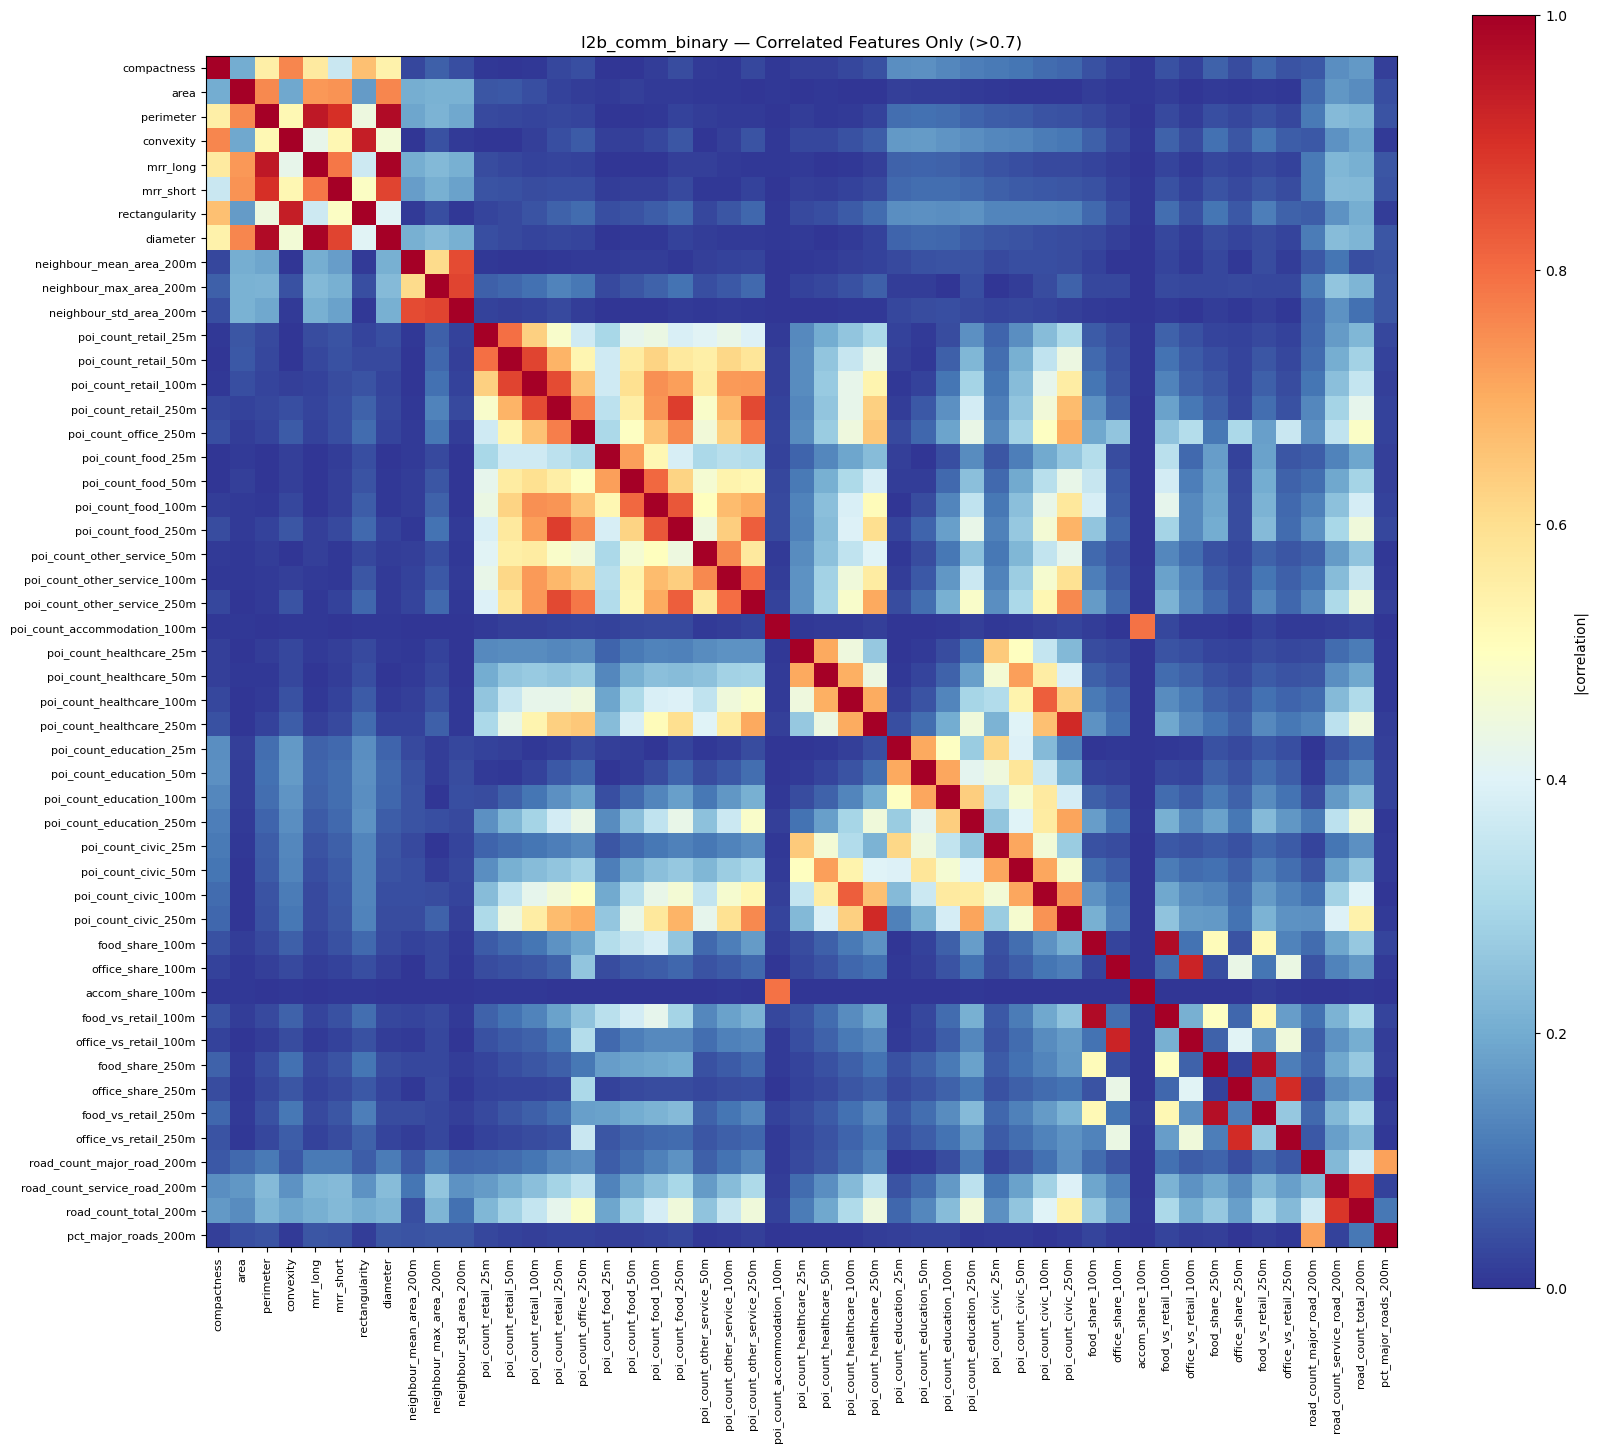

In [4]:
# too many features to view, only show features with correlation above a certain threshold

FILTER_THRESHOLD = 0.7  # lower bar just for what gets INCLUDED in the plot


# Keep only features that have at least one other-feature correlation above FILTER_THRESHOLD
np.fill_diagonal(corr_matrix.values, 0)  # ignore self-correlation
has_strong_corr = corr_matrix.max(axis=1) > FILTER_THRESHOLD
plot_features = corr_matrix.index[has_strong_corr].tolist()

# print features not included in the plot
excluded_features = corr_matrix.index[~has_strong_corr].tolist()
print(f"Excluded features (correlation <= {FILTER_THRESHOLD} with all other features):")
print(excluded_features)

print(f"{len(plot_features)} / {len(candidate_features)} features have a correlation > {FILTER_THRESHOLD} with something else")

corr_subset = X_train[plot_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(plot_features)*0.35), max(6, len(plot_features)*0.3)))
im = ax.imshow(corr_subset, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(plot_features))); ax.set_xticklabels(plot_features, rotation=90, fontsize=8)
ax.set_yticks(range(len(plot_features))); ax.set_yticklabels(plot_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Correlated Features Only (>{FILTER_THRESHOLD})')
plt.tight_layout()
plt.show()

Excluded features (correlation <= 0.9 with all other features):
['address_tier', 'compactness', 'area', 'num_vertices', 'mrr_short', 'elongation', 'dist_nearest_real_building', 'is_touching_real_building', 'real_touching_count', 'dist_to_residential', 'dist_to_commercial', 'dist_to_industrial', 'dist_to_agricultural', 'buildings_in_same_zone', 'zone_total_area', 'building_area_fraction', 'zone_building_density', 'neighbour_mean_area_200m', 'neighbour_max_area_200m', 'neighbour_std_area_200m', 'poi_count_retail_25m', 'poi_count_retail_50m', 'poi_count_retail_100m', 'poi_count_retail_250m', 'poi_count_office_25m', 'poi_count_office_50m', 'poi_count_office_100m', 'poi_count_office_250m', 'poi_count_food_25m', 'poi_count_food_50m', 'poi_count_food_100m', 'poi_count_food_250m', 'poi_count_other_service_25m', 'poi_count_other_service_50m', 'poi_count_other_service_100m', 'poi_count_other_service_250m', 'poi_count_accommodation_25m', 'poi_count_accommodation_50m', 'poi_count_accommodation_100

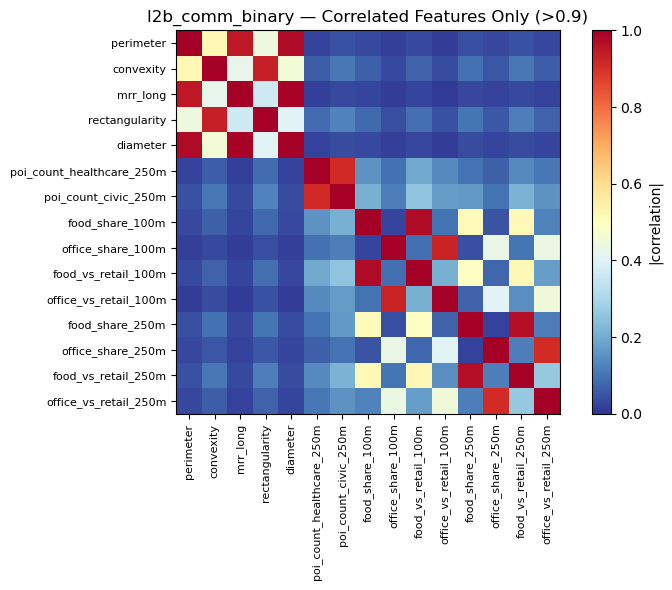

In [5]:

FILTER_THRESHOLD = 0.9  # lower bar just for what gets INCLUDED in the plot


# Keep only features that have at least one other-feature correlation above FILTER_THRESHOLD
np.fill_diagonal(corr_matrix.values, 0)  # ignore self-correlation
has_strong_corr = corr_matrix.max(axis=1) > FILTER_THRESHOLD
plot_features = corr_matrix.index[has_strong_corr].tolist()

# print features not included in the plot
excluded_features = corr_matrix.index[~has_strong_corr].tolist()
print(f"Excluded features (correlation <= {FILTER_THRESHOLD} with all other features):")
print(excluded_features)

print(f"{len(plot_features)} / {len(candidate_features)} features have a correlation > {FILTER_THRESHOLD} with something else")

corr_subset = X_train[plot_features].corr().abs()

fig, ax = plt.subplots(figsize=(max(8, len(plot_features)*0.35), max(6, len(plot_features)*0.3)))
im = ax.imshow(corr_subset, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(len(plot_features))); ax.set_xticklabels(plot_features, rotation=90, fontsize=8)
ax.set_yticks(range(len(plot_features))); ax.set_yticklabels(plot_features, fontsize=8)
fig.colorbar(im, ax=ax, label='|correlation|')
ax.set_title(f'{LEVEL} — Correlated Features Only (>{FILTER_THRESHOLD})')
plt.tight_layout()
plt.show()

In [6]:
# Ranked List of Correlated Pairs
CORR_THRESHOLD = 0.90

pairs = []
for i, c1 in enumerate(candidate_features):
    for c2 in candidate_features[i+1:]:
        r = corr_matrix.loc[c1, c2]
        if r > CORR_THRESHOLD:
            pairs.append((c1, c2, round(r, 3)))

pairs_df = pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'abs_corr']).sort_values('abs_corr', ascending=False)
print(f"{len(pairs_df)} pairs above {CORR_THRESHOLD}:\n")
pairs_df

9 pairs above 0.9:



,feature_1,feature_2,abs_corr
3,mrr_long,diameter,0.990
5,food_share_100m,food_vs_retail_100m,0.975
1,perimeter,diameter,0.973
7,food_share_250m,food_vs_retail_250m,0.968
0,perimeter,mrr_long,0.947
2,convexity,rectangularity,0.937
6,office_share_100m,office_vs_retail_100m,0.924
4,poi_count_healthcare_250m,poi_count_civic_250m,0.914
8,office_share_250m,office_vs_retail_250m,0.907


In [7]:
CORR_DROP = ['perimeter', 'diameter', 'food_vs_retail_100m', 'food_vs_retail_250m',
'convexity', 'office_vs_retail_100m', 'dist_nearest_building', 'office_vs_retail_250m',
'touching_building_count', 'poi_count_healthcare_250m', 'is_touching_building'
]

kept_after_corr = [c for c in candidate_features if c not in CORR_DROP]
print(f"Dropped {len(CORR_DROP)} by hand: {CORR_DROP}")
print(f"Remaining: {len(kept_after_corr)} / {len(candidate_features)}")

Dropped 11 by hand: ['perimeter', 'diameter', 'food_vs_retail_100m', 'food_vs_retail_250m', 'convexity', 'office_vs_retail_100m', 'dist_nearest_building', 'office_vs_retail_250m', 'touching_building_count', 'poi_count_healthcare_250m', 'is_touching_building']
Remaining: 102 / 110


Training until validation scores don't improve for 100 rounds
[500]	train's binary_logloss: 0.322178	val's binary_logloss: 0.326811
[1000]	train's binary_logloss: 0.306179	val's binary_logloss: 0.317977
[1500]	train's binary_logloss: 0.294134	val's binary_logloss: 0.312239
[2000]	train's binary_logloss: 0.283952	val's binary_logloss: 0.308041
[2500]	train's binary_logloss: 0.274695	val's binary_logloss: 0.304478
Did not meet early stopping. Best iteration is:
[2500]	train's binary_logloss: 0.274695	val's binary_logloss: 0.304478

BASELINE VAL PERFORMANCE — l2b_comm_binary  (102 features)
Macro F1    : 0.8641
Weighted F1 : 0.8712

              precision    recall  f1-score   support

           0     0.8817    0.9120    0.8966     32785
           1     0.8552    0.8094    0.8317     21046

    accuracy                         0.8719     53831
   macro avg     0.8684    0.8607    0.8641     53831
weighted avg     0.8713    0.8719    0.8712     53831



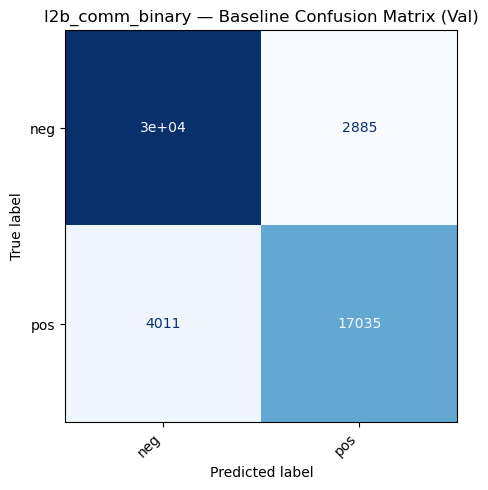

In [8]:
baseline_params = dict(
    n_estimators=2500, learning_rate=0.05, n_jobs=-1,
    random_state=42, verbosity=-1, importance_type='gain'
)
if n_classes == 2:
    lgb_baseline = lgb.LGBMClassifier(objective='binary', eval_metric='binary_logloss', **baseline_params)
else:
    lgb_baseline = lgb.LGBMClassifier(objective='multiclass', num_class=n_classes, eval_metric='multi_logloss', **baseline_params)

baseline_model = lgb_baseline

lgb_baseline.fit(
    X_train[kept_after_corr], y_train,
    eval_set=[(X_train[kept_after_corr], y_train), (X_val[kept_after_corr], y_val)],
    eval_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=500),   # prints progress every 500 rounds
    ]
)
gain_importance = pd.Series(baseline_model.feature_importances_, index=kept_after_corr).sort_values(ascending=False)
y_val_pred = baseline_model.predict(X_val[kept_after_corr])

avg_type = 'macro' if n_classes > 2 else 'binary'
baseline_macro_f1    = f1_score(y_val, y_val_pred, average='macro')
baseline_weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"\n{'='*60}")
print(f"BASELINE VAL PERFORMANCE — {LEVEL}  ({len(kept_after_corr)} features)")
print(f"{'='*60}")
print(f"Macro F1    : {baseline_macro_f1:.4f}")
print(f"Weighted F1 : {baseline_weighted_f1:.4f}\n")

target_names = classes if n_classes > 2 else None
print(classification_report(y_val, y_val_pred, target_names=target_names, digits=4))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_val_pred)
disp_labels = classes if n_classes > 2 else ['neg', 'pos']
ConfusionMatrixDisplay(cm, display_labels=disp_labels).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{LEVEL} — Baseline Confusion Matrix (Val)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


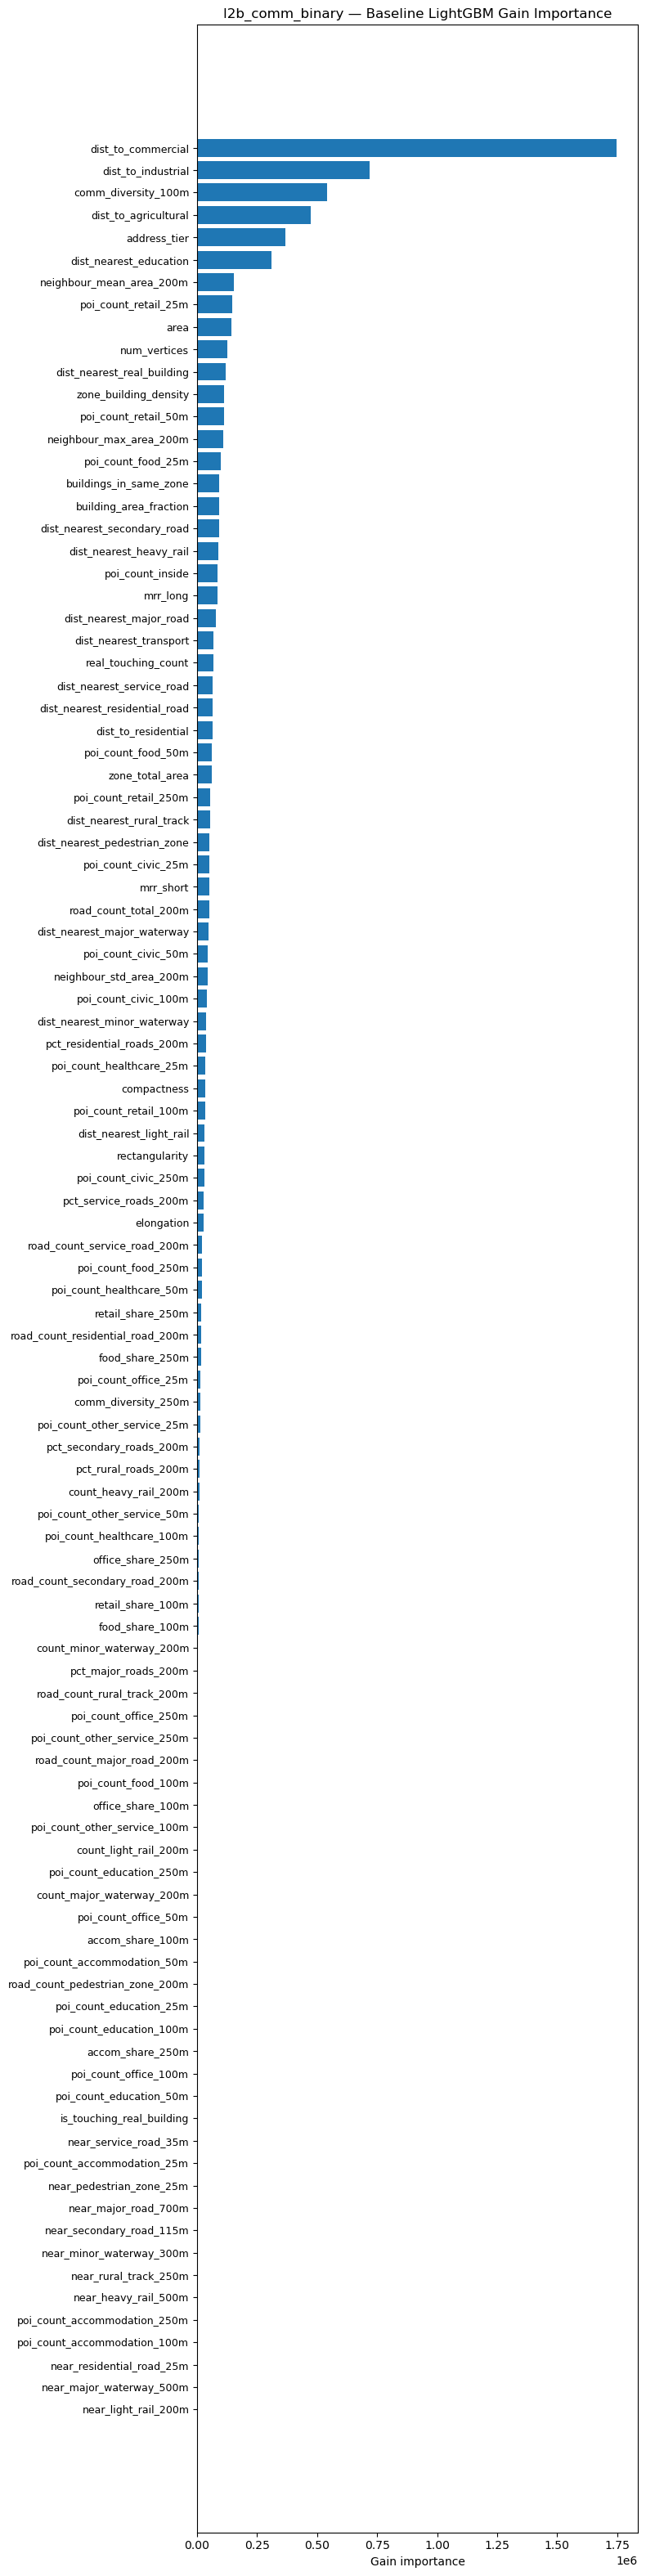

In [9]:
gain_importance = pd.Series(baseline_model.feature_importances_, index=kept_after_corr).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, len(kept_after_corr)*0.3 + 1))
ax.barh(range(len(gain_importance)), gain_importance.values[::-1])
ax.set_yticks(range(len(gain_importance)))
ax.set_yticklabels(gain_importance.index[::-1], fontsize=9)
ax.set_xlabel('Gain importance')
ax.set_title(f'{LEVEL} — Baseline LightGBM Gain Importance')
plt.tight_layout()
plt.show()

[0]	validation_0-logloss:0.64890	validation_1-logloss:0.64884
[500]	validation_0-logloss:0.32054	validation_1-logloss:0.32854
[1000]	validation_0-logloss:0.29945	validation_1-logloss:0.31628
[1500]	validation_0-logloss:0.28465	validation_1-logloss:0.30935
[2000]	validation_0-logloss:0.27172	validation_1-logloss:0.30421
[2499]	validation_0-logloss:0.26079	validation_1-logloss:0.30045

Stopped at iteration: 2499

BASELINE VAL PERFORMANCE — l2b_comm_binary  (102 features)
Macro F1    : 0.8654
Weighted F1 : 0.8724

              precision    recall  f1-score   support

           0     0.8830    0.9124    0.8975     32785
           1     0.8561    0.8116    0.8333     21046

    accuracy                         0.8730     53831
   macro avg     0.8695    0.8620    0.8654     53831
weighted avg     0.8725    0.8730    0.8724     53831



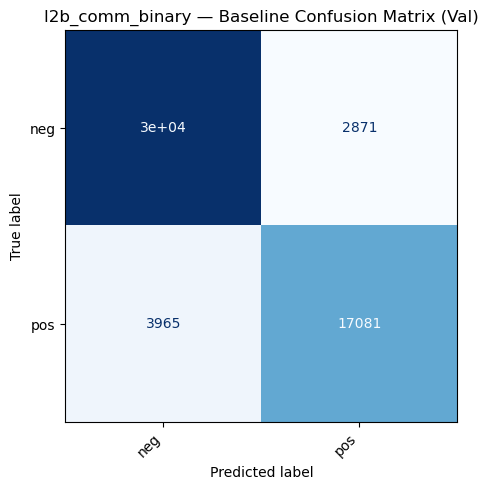

In [10]:
#  XGBoost Baseline 
xgb_eval_metric = 'logloss' if n_classes == 2 else 'mlogloss'

xgb_params = dict(
    n_estimators=2500,
    learning_rate=0.05,
    n_jobs=-1, random_state=42,
    eval_metric=xgb_eval_metric,
    early_stopping_rounds=50,
)
if n_classes == 2:
    xgb_baseline = xgb.XGBClassifier(objective='binary:logistic', **xgb_params)
else:
    xgb_baseline = xgb.XGBClassifier(objective='multi:softprob', num_class=n_classes, **xgb_params)

xgb_baseline.fit(
    X_train[kept_after_corr], y_train,
    eval_set=[(X_train[kept_after_corr], y_train), (X_val[kept_after_corr], y_val)],
    verbose=500
)

print(f"\nStopped at iteration: {xgb_baseline.best_iteration}")
y_val_pred = xgb_baseline.predict(X_val[kept_after_corr])

avg_type = 'macro' if n_classes > 2 else 'binary'
xgb_macro_f1    = f1_score(y_val, y_val_pred, average='macro')
xgb_weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f"\n{'='*60}")
print(f"BASELINE VAL PERFORMANCE — {LEVEL}  ({len(kept_after_corr)} features)")
print(f"{'='*60}")
print(f"Macro F1    : {xgb_macro_f1:.4f}")
print(f"Weighted F1 : {xgb_weighted_f1:.4f}\n")

target_names = classes if n_classes > 2 else None
print(classification_report(y_val, y_val_pred, target_names=target_names, digits=4))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_val_pred)
disp_labels = classes if n_classes > 2 else ['neg', 'pos']
ConfusionMatrixDisplay(cm, display_labels=disp_labels).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{LEVEL} — Baseline Confusion Matrix (Val)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [11]:
# ── XGBoost gain importance — compare ranking against LightGBM's ──
xgb_importance = pd.Series(
    xgb_baseline.get_booster().get_score(importance_type='gain'),
    name='xgb_gain'
)
xgb_importance = xgb_importance.sort_values(ascending=False)

comparison = pd.DataFrame({
    'lightgbm_rank': gain_importance.rank(ascending=False),
    'xgboost_rank' : xgb_importance.reindex(gain_importance.index).rank(ascending=False)
}).sort_values('lightgbm_rank')
print("\nTop features — rank agreement between LightGBM and XGBoost:")
comparison.head(20)


Top features — rank agreement between LightGBM and XGBoost:


,lightgbm_rank,xgboost_rank
dist_to_commercial,1.0,2.0
dist_to_industrial,2.0,9.0
comm_diversity_100m,3.0,1.0
dist_to_agricultural,4.0,12.0
address_tier,5.0,6.0
dist_nearest_education,6.0,19.0
neighbour_mean_area_200m,7.0,28.0
poi_count_retail_25m,8.0,4.0
area,9.0,26.0
num_vertices,10.0,20.0


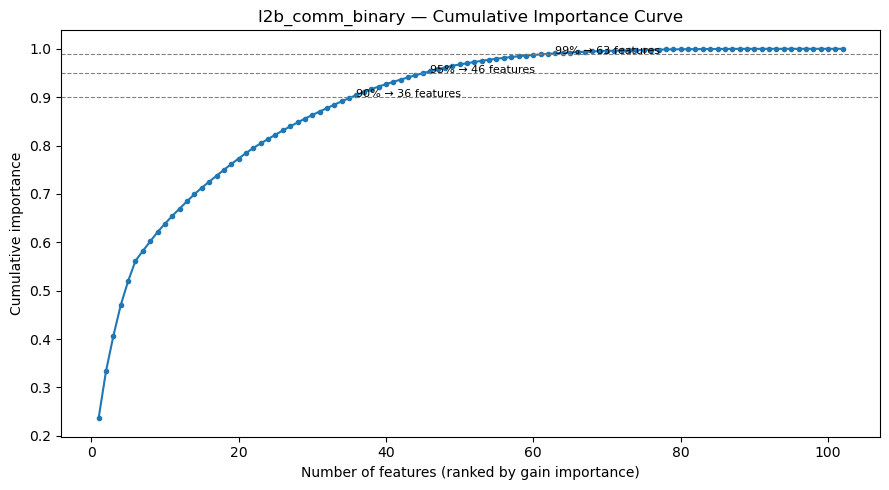

In [12]:
# Cumulative Importance 
cum_importance = gain_importance.cumsum() / gain_importance.sum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cum_importance)+1), cum_importance.values, marker='o', markersize=3)
for pct in [0.90, 0.95, 0.99]:
    ax.axhline(pct, linestyle='--', color='gray', linewidth=0.8)
    n_at_pct = (cum_importance <= pct).sum() + 1
    ax.annotate(f'{int(pct*100)}% → {n_at_pct} features', xy=(n_at_pct, pct), fontsize=8)
ax.set_xlabel('Number of features (ranked by gain importance)')
ax.set_ylabel('Cumulative importance')
ax.set_title(f'{LEVEL} — Cumulative Importance Curve')
plt.tight_layout()
plt.show()

In [17]:
# Reconciling LightGBM vs XGBoost rank disagreement
TOP_N = 63

lgb_top = set(comparison.sort_values('lightgbm_rank').head(TOP_N).index)
xgb_top = set(comparison.sort_values('xgboost_rank').head(TOP_N).index)

both_agree   = lgb_top & xgb_top   # strong keep — both models independently value these
lgb_only     = lgb_top - xgb_top   # LightGBM-favored 
xgb_only     = xgb_top - lgb_top   # XGBoost-favored 
neither      = set(comparison.index) - lgb_top - xgb_top   # both models agree these are weak

print(f"Both models rank in top {TOP_N}: {len(both_agree)}")
print(sorted(both_agree))
print(f"\nLightGBM-only top {TOP_N} (geometry-leaning?): {len(lgb_only)}")
print(sorted(lgb_only))
print(f"\nXGBoost-only top {TOP_N} (POI-count-leaning?): {len(xgb_only)}")
print(sorted(xgb_only))
print(f"\nBoth models agree these are weak — safe drop candidates: {len(neither)}")
print(sorted(neither))

union_selection = both_agree | lgb_only | xgb_only
selected_features = list(union_selection)  # convert to list for indexing
print(f"\nUnion selection: {len(union_selection)} features")

Both models rank in top 63: 56
['address_tier', 'area', 'building_area_fraction', 'buildings_in_same_zone', 'comm_diversity_100m', 'compactness', 'dist_nearest_education', 'dist_nearest_heavy_rail', 'dist_nearest_light_rail', 'dist_nearest_major_road', 'dist_nearest_pedestrian_zone', 'dist_nearest_real_building', 'dist_nearest_residential_road', 'dist_nearest_rural_track', 'dist_nearest_secondary_road', 'dist_nearest_service_road', 'dist_nearest_transport', 'dist_to_agricultural', 'dist_to_commercial', 'dist_to_industrial', 'dist_to_residential', 'elongation', 'food_share_250m', 'mrr_long', 'mrr_short', 'neighbour_max_area_200m', 'neighbour_mean_area_200m', 'neighbour_std_area_200m', 'num_vertices', 'pct_residential_roads_200m', 'pct_service_roads_200m', 'poi_count_civic_100m', 'poi_count_civic_250m', 'poi_count_civic_25m', 'poi_count_civic_50m', 'poi_count_food_250m', 'poi_count_food_25m', 'poi_count_food_50m', 'poi_count_healthcare_100m', 'poi_count_healthcare_25m', 'poi_count_health

In [18]:
# Before/After Sanity Check

model_full = type(baseline_model)(**baseline_model.get_params())
model_full.fit(X_train[candidate_features], y_train)
pred_full = model_full.predict(X_val[candidate_features])

model_reduced = type(baseline_model)(**baseline_model.get_params())
model_reduced.fit(X_train[selected_features], y_train)
pred_reduced = model_reduced.predict(X_val[selected_features])

avg = 'macro' if n_classes > 2 else 'binary'
f1_full    = f1_score(y_val, pred_full, average=avg)
f1_reduced = f1_score(y_val, pred_reduced, average=avg)

print(f"F1 (val) — full pool ({len(candidate_features)} feats)     : {f1_full:.4f}")
print(f"F1 (val) — selected  ({len(selected_features)} feats)      : {f1_reduced:.4f}")
print(f"Difference: {f1_reduced - f1_full:+.4f}")

F1 (val) — full pool (110 feats)     : 0.8313
F1 (val) — selected  (70 feats)      : 0.8318
Difference: +0.0005


In [15]:
# Try more aggressive cuts
for n in [30, 40, 50, 60, 73]:
    trial_features = list(gain_importance.index[:n])
    model_trial = type(baseline_model)(**baseline_model.get_params())
    model_trial.fit(X_train[trial_features], y_train)
    pred_trial = model_trial.predict(X_val[trial_features])
    f1_trial = f1_score(y_val, pred_trial, average='macro' if n_classes > 2 else 'binary')
    print(f"N={n:>3}: F1={f1_trial:.4f}  (diff from full: {f1_trial - f1_full:+.4f})")

N= 30: F1=0.8187  (diff from full: -0.0127)
N= 40: F1=0.8257  (diff from full: -0.0056)
N= 50: F1=0.8300  (diff from full: -0.0014)
N= 60: F1=0.8315  (diff from full: +0.0002)
N= 73: F1=0.8307  (diff from full: -0.0006)


In [19]:
joblib.dump(selected_features, os.path.join(MODEL_DIR, f'{LEVEL}_feature_cols.pkl'))
feature_cols = selected_features
X_train = X_train[selected_features].values
X_val   = X_val[selected_features].values
X_test  = X_test[selected_features].values

In [20]:
# Evaluation Helper (used by every model)

def evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, level, threshold=0.5):
    results = {}
    for split_name, X_sp, y_sp in [('val', X_val, y_val), ('test', X_test, y_test)]:
        
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_sp)[:, 1]
            y_pred = (y_prob >= threshold).astype(int)
        else:
            y_pred = model.predict(X_sp).astype(int)

        report = classification_report(y_sp, y_pred, target_names=classes, output_dict=True)
        macro_f1 = f1_score(y_sp, y_pred, average='macro')
        weighted_f1 = f1_score(y_sp, y_pred, average='weighted')
        
        results[split_name] = {
            'macro_f1'   : round(macro_f1, 4),
            'weighted_f1': round(weighted_f1, 4),
            'report'     : report,
            'threshold'  : round(threshold, 3)
        }
        print(f"\n{model_name} — {split_name.upper()} (Decision Threshold: {threshold:.3f})")
        print(f"  Macro F1    : {macro_f1:.4f}")
        print(f"  Weighted F1 : {weighted_f1:.4f}")
        print(classification_report(y_sp, y_pred, target_names=classes, digits=4))

    if hasattr(model, "predict_proba"):
        y_prob_test = model.predict_proba(X_test)[:, 1]
        y_pred_test = (y_prob_test >= threshold).astype(int)
    else:
        y_pred_test = model.predict(X_test).astype(int)

    cm = confusion_matrix(y_test, y_pred_test)
    fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes-1)))
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False)
    ax.set_title(f'{model_name} — {level} — Test Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{level}_{model_name}_confusion.png'), dpi=150)
    plt.show()

    return results


all_results = {}  # accumulates results from all models for comparison

In [21]:
# Optuna Hyperparameter Optimization (Fast Subsampled Search)

N_TRIALS = 20
TUNING_FRACTION = 0.50
n_sub = int(len(X_train) * TUNING_FRACTION)

sss = StratifiedShuffleSplit(n_splits=1, train_size=n_sub, random_state=42)
sub_idx, _ = next(sss.split(X_train, y_train))
X_train_sub, y_train_sub = X_train[sub_idx], y_train[sub_idx]

print(f"Running hyperparameter optimization on {n_sub:,} rows ({TUNING_FRACTION*100}% sample)...")

def objective_lightgbm(trial):
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'n_estimators': 3000,
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.12, log=True),
        'max_depth': -1, 
        'num_leaves': trial.suggest_int('num_leaves', 63, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 50, 500),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.2, 3.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 1e-3, 1.0, log=True),
        'random_state': 42,
        'verbosity': -1
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train_sub, y_train_sub,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    preds = model.predict(X_val)
    return f1_score(y_val, preds, pos_label=1, average='binary')

def objective_xgboost(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'n_estimators': 3000,
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.12, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 12), 
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.2, 3.0),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50, log=True),
        'tree_method': 'hist',
        'early_stopping_rounds': 50,
        'n_jobs': -1,
        'random_state': 42
    }
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train_sub, y_train_sub,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    preds = model.predict(X_val)
    return f1_score(y_val, preds, pos_label=1, average='binary')

print("Optimizing LightGBM...")
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lightgbm, n_trials=N_TRIALS, show_progress_bar=True)
best_lgb_params = study_lgb.best_params
print("Best LightGBM Params:", best_lgb_params)

print("\nOptimizing XGBoost...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgboost, n_trials=N_TRIALS, show_progress_bar=True)
best_xgb_params = study_xgb.best_params

print("\nTuning Complete!")

# save the best hyperparameters for reference
with open(os.path.join(MODEL_DIR, f'{LEVEL}_best_hyperparameters.json'), 'w') as f:
    json.dump({'lightgbm': best_lgb_params, 'xgboost': best_xgb_params}, f, indent=4)



Running hyperparameter optimization on 457,557 rows (50.0% sample)...
Optimizing LightGBM...


Best trial: 17. Best value: 0.846117: 100%|██████████████████████████| 20/20 [2:50:05<00:00, 510.25s/it]


Best LightGBM Params: {'learning_rate': 0.051922644792951125, 'num_leaves': 210, 'min_child_samples': 404, 'subsample': 0.9957077752239444, 'colsample_bytree': 0.783674685465808, 'scale_pos_weight': 2.498920730736849, 'reg_alpha': 1.7310036301702785, 'reg_lambda': 0.1015849042171487, 'min_split_gain': 0.024400550400216874}

Optimizing XGBoost...


Best trial: 19. Best value: 0.846641: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [27:25<00:00, 82.28s/it]


Tuning Complete!



Training finalized LIGHTGBM on 100% data...
Training until validation scores don't improve for 150 rounds
[200]	valid_0's binary_logloss: 0.351128
[400]	valid_0's binary_logloss: 0.335927
[600]	valid_0's binary_logloss: 0.326966
[800]	valid_0's binary_logloss: 0.319647
[1000]	valid_0's binary_logloss: 0.314452
[1200]	valid_0's binary_logloss: 0.309852
[1400]	valid_0's binary_logloss: 0.30609
[1600]	valid_0's binary_logloss: 0.302699
[1800]	valid_0's binary_logloss: 0.300053
[2000]	valid_0's binary_logloss: 0.297422
[2200]	valid_0's binary_logloss: 0.295194
[2400]	valid_0's binary_logloss: 0.293412
[2600]	valid_0's binary_logloss: 0.291575
[2800]	valid_0's binary_logloss: 0.29001
[3000]	valid_0's binary_logloss: 0.288666
[3200]	valid_0's binary_logloss: 0.287518
[3400]	valid_0's binary_logloss: 0.286387
[3600]	valid_0's binary_logloss: 0.285314
[3800]	valid_0's binary_logloss: 0.284438
[4000]	valid_0's binary_logloss: 0.283665
[4200]	valid_0's binary_logloss: 0.282916
[4400]	valid_0's 

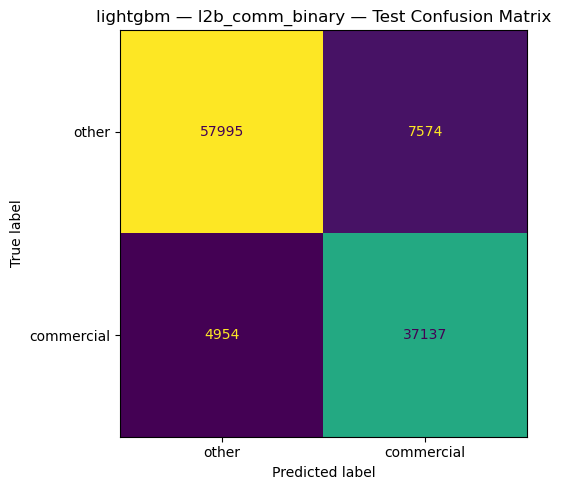


xgboost — VAL (Decision Threshold: 0.500)
  Macro F1    : 0.8834
  Weighted F1 : 0.8885
              precision    recall  f1-score   support

       other     0.9205    0.8934    0.9067     32785
  commercial     0.8412    0.8797    0.8600     21046

    accuracy                         0.8880     53831
   macro avg     0.8808    0.8866    0.8834     53831
weighted avg     0.8895    0.8880    0.8885     53831


xgboost — TEST (Decision Threshold: 0.500)
  Macro F1    : 0.8809
  Weighted F1 : 0.8861
              precision    recall  f1-score   support

       other     0.9193    0.8904    0.9046     65569
  commercial     0.8372    0.8783    0.8573     42091

    accuracy                         0.8856    107660
   macro avg     0.8783    0.8843    0.8809    107660
weighted avg     0.8872    0.8856    0.8861    107660



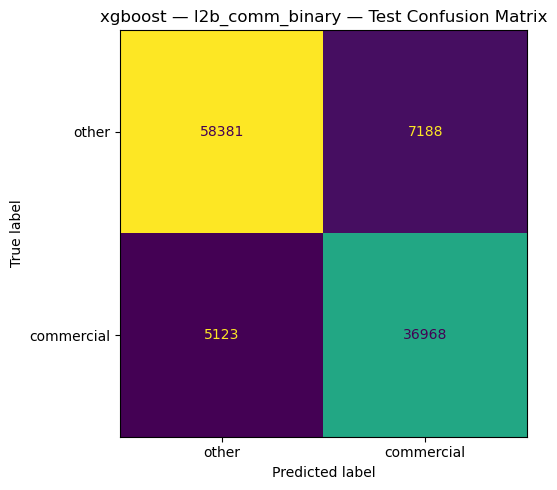

In [22]:
with open(os.path.join(MODEL_DIR, f'{LEVEL}_best_hyperparameters.json'), 'r') as f:
    best_params = json.load(f)

best_lgb_params = best_params['lightgbm']
best_xgb_params = best_params['xgboost']

# Define full dataset model using optimized configurations
FINAL_CONFIGS = {
    'lightgbm': {
        'cls': lgb.LGBMClassifier,
        'params': {
            'objective': 'binary', 'metric': 'binary_logloss', 'boosting_type': 'gbdt',
            'n_estimators': 25000, 'importance_type': 'gain',
            'n_jobs': -1, 'random_state': 42, 'verbosity': -1, **best_lgb_params, 'max_depth': -1
        },
        'fit_kwargs': {'eval_set': [(X_val, y_val)], 'callbacks': [lgb.early_stopping(150), lgb.log_evaluation(200)]}
    },
    'xgboost': {
        'cls': xgb.XGBClassifier,
        'params': {
            'objective': 'binary:logistic', 'eval_metric': 'logloss',
            'n_estimators': 25000, 'tree_method': 'hist', 'importance_type': 'gain',
            'early_stopping_rounds': 150, 'n_jobs': -1, 'random_state': 42, **best_xgb_params
        },
        'fit_kwargs': {'eval_set': [(X_val, y_val)], 'verbose': 200}
    }
}

trained_models = {}

for model_name, cfg in FINAL_CONFIGS.items():
    print(f"\n{'='*60}\nTraining finalized {model_name.upper()} on 100% data...\n{'='*60}")
    
    model = cfg['cls'](**cfg['params'])
    model.fit(X_train, y_train, **cfg['fit_kwargs'])
    
    save_path = os.path.join(MODEL_DIR, f'{LEVEL}_{model_name}_optimized.pkl')
    joblib.dump(model, save_path)
    trained_models[model_name] = model
    print(f"Saved base model pipeline → {save_path}")

print(f"\n{'='*60}\nBASELINE TEST SET EVALUATION (Default 0.5 Threshold)\n{'='*60}")
for model_name, model in trained_models.items():
    all_results[model_name] = evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, LEVEL, threshold=0.5)

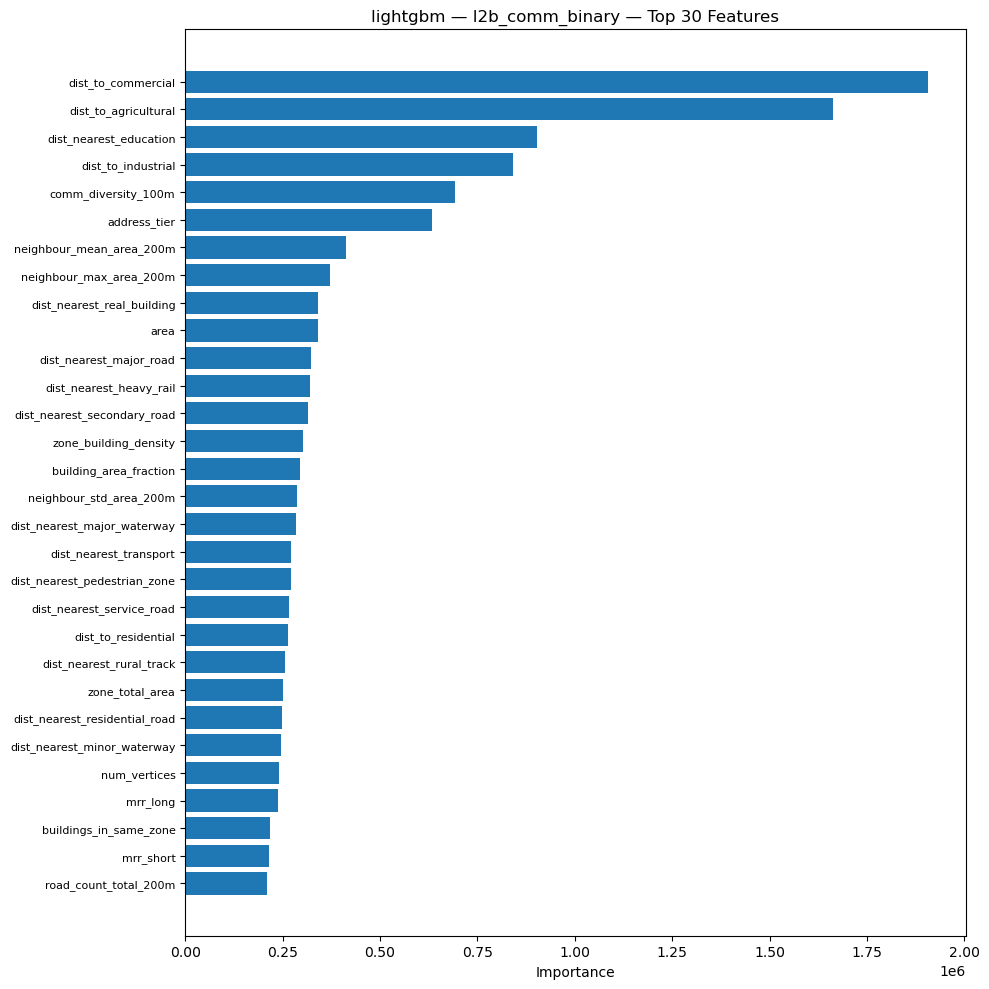

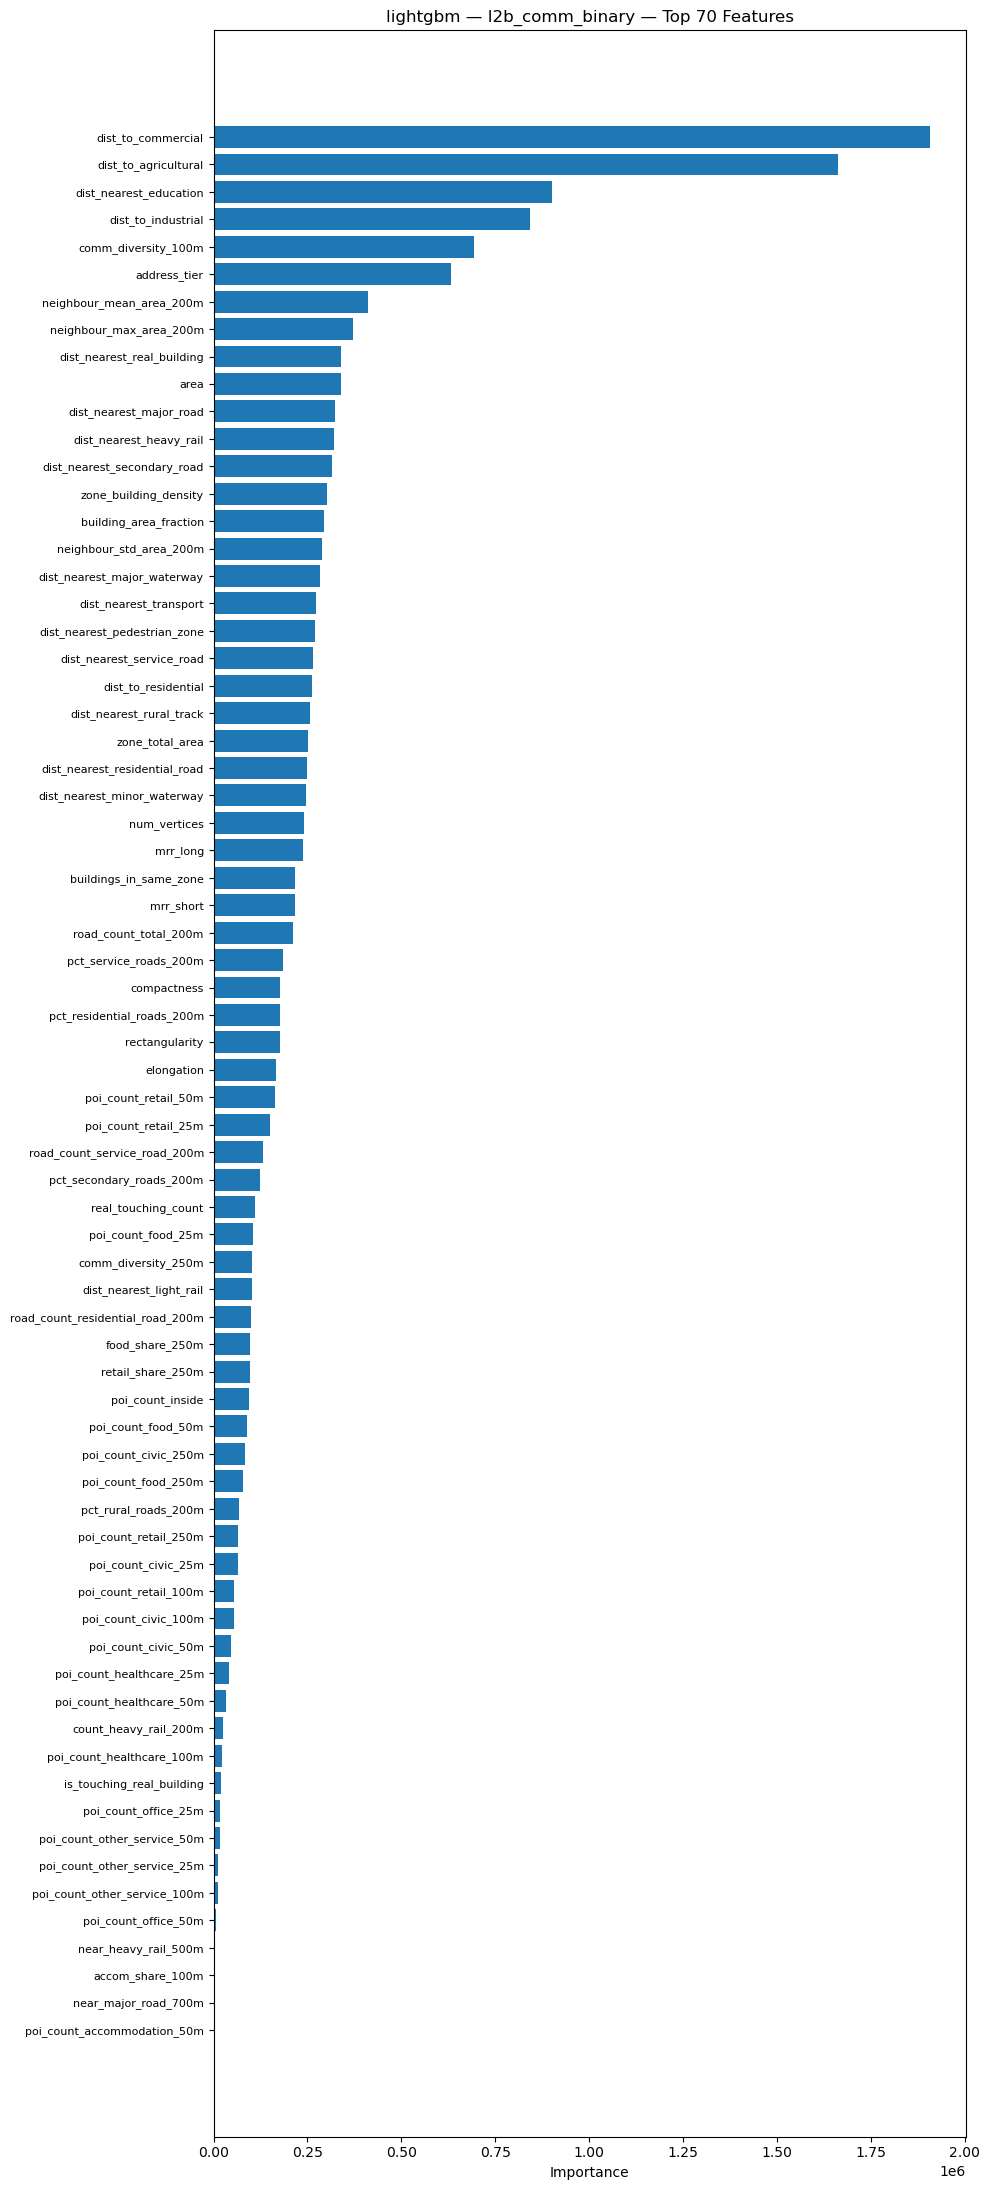

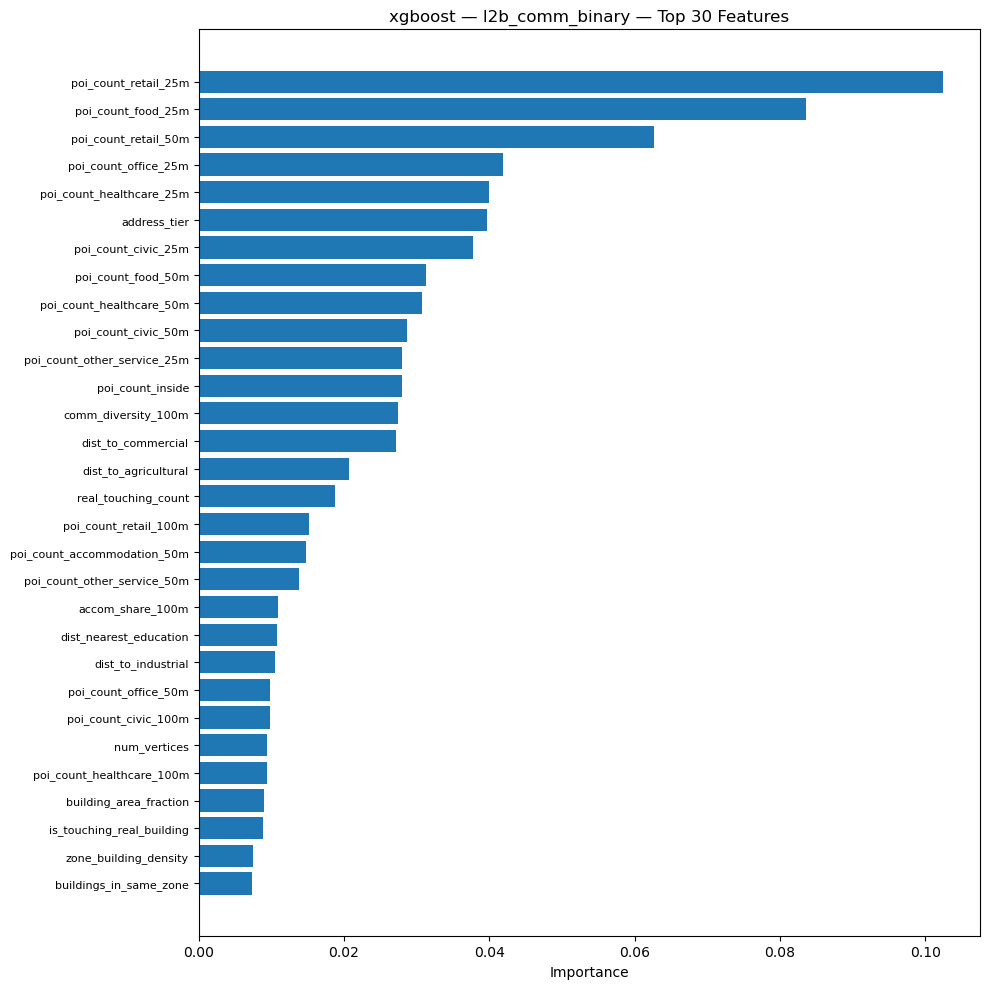

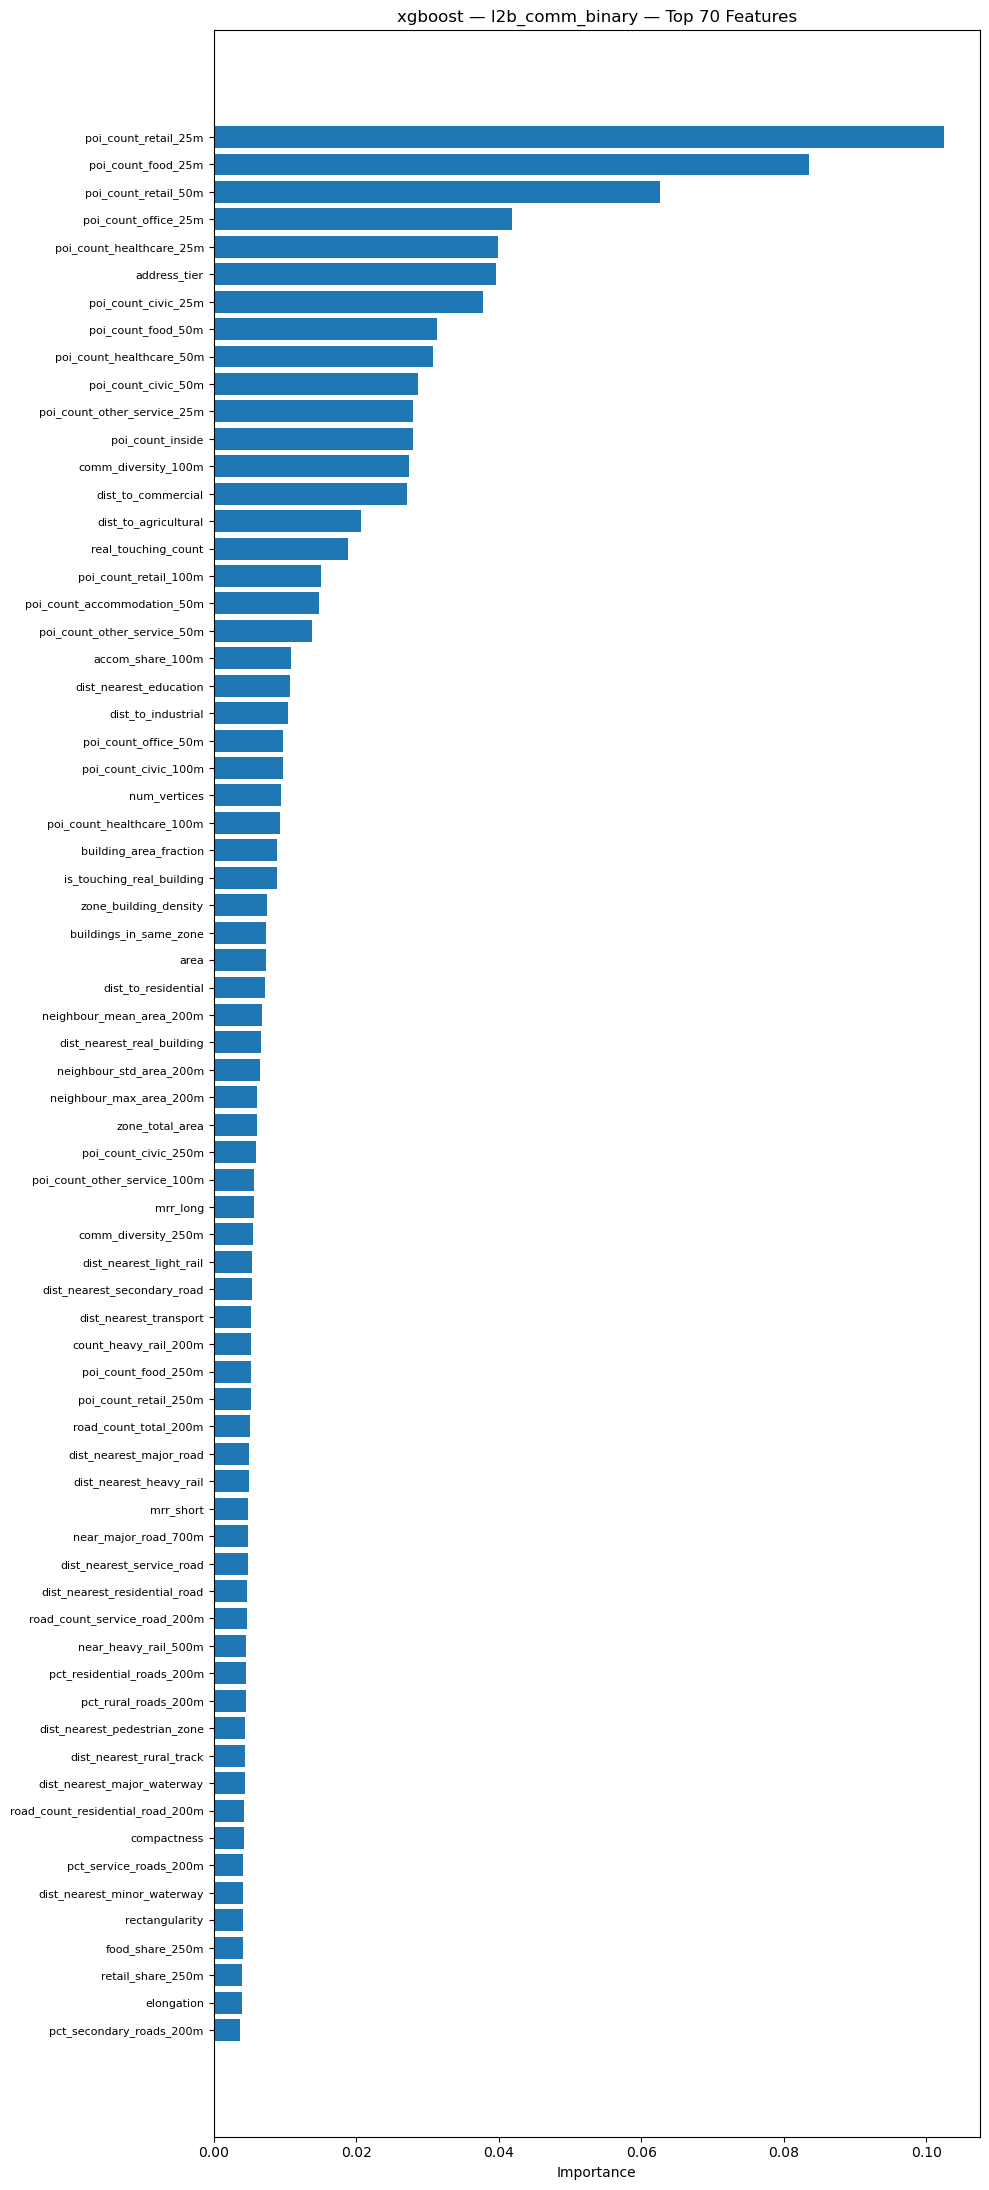

In [23]:
# Feature Importance 
def plot_feature_importance(model, model_name, feature_cols, level, top_n=30):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    else:
        return

    idx  = np.argsort(imp)[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(10, top_n * 0.3 + 1))
    ax.barh(range(top_n), imp[idx][::-1])
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_cols[i] for i in idx[::-1]], fontsize=8)
    ax.set_title(f'{model_name} — {level} — Top {top_n} Features')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{level}_{model_name}_importance.png'), dpi=120)
    plt.show()

for model_name, model in trained_models.items():
    plot_feature_importance(model, model_name, feature_cols, LEVEL)
    plot_feature_importance(model, model_name, feature_cols, LEVEL, len(feature_cols))

In [24]:
print(f"\n{'='*60}")
print(f"MODEL COMPARISON — {LEVEL} — TEST SET")
print(f"{'='*60}")
print(f"{'Model':<20} {'Macro F1':>10} {'Weighted F1':>13}")
print("-" * 45)

for model_name, res in all_results.items():
    mf1 = res['test']['macro_f1']
    wf1 = res['test']['weighted_f1']
    print(f"{model_name:<20} {mf1:>10.4f} {wf1:>13.4f}")

# Save results to JSON for later aggregation
results_path = os.path.join(MODEL_DIR, f'{LEVEL}_results.json')
# Make results JSON-serialisable
serialisable = {
    m: {s: {k: v for k, v in r.items() if k != 'report'}
        for s, r in res.items()}
    for m, res in all_results.items()
}
with open(results_path, 'w') as f:
    json.dump(serialisable, f, indent=2)
print(f"\nResults saved → {results_path}")


MODEL COMPARISON — l2b_comm_binary — TEST SET
Model                  Macro F1   Weighted F1
---------------------------------------------
lightgbm                 0.8791        0.8842
xgboost                  0.8809        0.8861

Results saved → /fast/home/o-olajuyigbe/osm_project/data/models/l2b_comm_binary_results.json


In [25]:
# Production Retraining (Train + Test) ONLY for the Winning Model

BEST_MODEL = 'xgboost'  

print(f"Preparing final production rollout strictly for the winning model: {BEST_MODEL.upper()}")

X_production_train = np.vstack([X_train, X_test])
y_production_train = np.concatenate([y_train, y_test])

X_production_val = X_val
y_production_val = y_val

print(f"Expanded Training Pool Size : {X_production_train.shape[0]:,} rows (95%)")
print(f"Early Stopping Validation Size: {X_production_val.shape[0]:,} rows (5%)")

if BEST_MODEL == 'lightgbm':
    print("Configuring final LightGBM pipeline...")
    prod_model = lgb.LGBMClassifier(
        objective='binary',
        metric='binary_logloss',
        boosting_type='gbdt',
        n_estimators=25000, 
        importance_type='gain',
        n_jobs=-1,
        random_state=42,
        verbosity=-1,
        **best_lgb_params,
        max_depth=-1 
    )
    fit_kwargs = {
        'eval_set': [(X_production_val, y_production_val)],
        'callbacks': [lgb.early_stopping(150), lgb.log_evaluation(200)]
    }
    
elif BEST_MODEL == 'xgboost':
    print("Configuring final XGBoost pipeline...")
    prod_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=25000, 
        tree_method='hist',
        early_stopping_rounds=150,
        n_jobs=-1, importance_type='gain',
        random_state=42,
        **best_xgb_params
    )
    fit_kwargs = {
        'eval_set': [(X_production_val, y_production_val)],
        'verbose': 200
    }
else:
    raise ValueError("Invalid BEST_MODEL name. Please enter either 'lightgbm' or 'xgboost'.")

print(f"\nRetraining {BEST_MODEL.upper()} on 95% of your dataset...")
prod_model.fit(X_production_train, y_production_train, **fit_kwargs)

production_save_path = os.path.join(MODEL_DIR, f'{LEVEL}_xgb_PRODUCTION_FINAL.pkl')

Preparing final production rollout strictly for the winning model: XGBOOST
Expanded Training Pool Size : 1,022,774 rows (95%)
Early Stopping Validation Size: 53,831 rows (5%)
Configuring final XGBoost pipeline...

Retraining XGBOOST on 95% of your dataset...


[0]	validation_0-logloss:0.75444
[200]	validation_0-logloss:0.36286
[400]	validation_0-logloss:0.34220
[600]	validation_0-logloss:0.32881
[800]	validation_0-logloss:0.31849
[1000]	validation_0-logloss:0.31037
[1200]	validation_0-logloss:0.30389
[1400]	validation_0-logloss:0.29827
[1600]	validation_0-logloss:0.29389
[1800]	validation_0-logloss:0.29005
[2000]	validation_0-logloss:0.28651
[2200]	validation_0-logloss:0.28372
[2400]	validation_0-logloss:0.28119
[2600]	validation_0-logloss:0.27920
[2800]	validation_0-logloss:0.27741
[3000]	validation_0-logloss:0.27603
[3200]	validation_0-logloss:0.27464
[3400]	validation_0-logloss:0.27362
[3600]	validation_0-logloss:0.27279
[3800]	validation_0-logloss:0.27228
[4000]	validation_0-logloss:0.27193
[4200]	validation_0-logloss:0.27169
[4319]	validation_0-logloss:0.27181

   Saved model to: /fast/home/o-olajuyigbe/osm_project/data/models/l2b_comm_binary_xgb_PRODUCTION_FINAL.pkl
